# 02 - Training Awal EfficientNet-B0

Notebook ini menjalankan eksperimen training awal untuk demo progress. Target sprint adalah pipeline training hidup dan menghasilkan metrik awal, bukan model final.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from cabai.config import CLASS_NAMES, RAW_DATA_DIR, INTERIM_DATA_DIR, CHECKPOINTS_DIR, FIGURES_DIR, REPORTS_DIR
from cabai.data import build_manifest, assign_missing_splits, make_dataloaders, write_manifest_csv
from cabai.model import create_model, get_device
from cabai.train import set_seed, fit_model
from cabai.evaluate import predict_loader, classification_metrics, plot_history, plot_confusion_matrix, save_metrics_json

set_seed(42)
device = get_device()
print('Device:', device)
print('Classes:', CLASS_NAMES)

Device: mps
Classes: ['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']


## Pilih Dataset Training

Kita akan melakukan training dengan menggunakan Kaggle sebagai percobaan awal.

In [2]:
roboflow_rows = build_manifest(RAW_DATA_DIR / 'roboflow_chili', dataset_name='roboflow_chili')
kaggle_rows = build_manifest(RAW_DATA_DIR / 'kaggle_penyakit_cabai', dataset_name='kaggle_penyakit_cabai')

if roboflow_rows:
    train_rows = roboflow_rows
    dataset_choice = 'roboflow_chili'
elif kaggle_rows:
    train_rows = kaggle_rows
    dataset_choice = 'kaggle_penyakit_cabai (fallback demo progress)'
else:
    raise FileNotFoundError(
        'Belum ada dataset lokal. Letakkan Roboflow di data/raw/roboflow_chili atau Kaggle di data/raw/kaggle_penyakit_cabai.'
    )

train_rows = assign_missing_splits(train_rows)
write_manifest_csv(train_rows, INTERIM_DATA_DIR / 'manifest_training.csv')
print('Dataset choice:', dataset_choice)
print('Total rows:', len(train_rows))

Dataset choice: kaggle_penyakit_cabai (fallback demo progress)
Total rows: 486


In [3]:
import pandas as pd

df = pd.DataFrame(train_rows)
display(pd.crosstab(df['split'], df['label']))

label,healthy,leaf curl,leaf spot,whitefly,yellowish
split,,,,,
test,10,10,10,10,10
train,80,79,78,72,77
val,10,10,10,10,10


## DataLoader dan Model

Model yang digunakan adalah EfficientNet-B0 transfer learning.

In [4]:
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 1e-3

loaders = make_dataloaders(train_rows, batch_size=BATCH_SIZE, num_workers=0)
print('Available splits:', list(loaders.keys()))

model = create_model('efficientnet_b0', num_classes=len(CLASS_NAMES), pretrained=True)

# Freeze backbone untuk demo training awal; classifier/head tetap dilatih.
for name, param in model.named_parameters():
    param.requires_grad = any(key in name.lower() for key in ['classifier', 'fc', 'head'])

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable_params:,} / {total_params:,}')

Available splits: ['train', 'val', 'test']
Trainable params: 642,945 / 4,013,953


In [5]:
checkpoint_path = CHECKPOINTS_DIR / 'efficientnet_b0_demo.pt'
history = fit_model(
    model,
    loaders,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    checkpoint_path=checkpoint_path,
)
print('Checkpoint:', checkpoint_path)

/Users/macbook/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



training:   0%|          | 0/5 [00:00<?, ?it/s]


training:  20%|██        | 1/5 [00:12<00:50, 12.62s/it]


training:  40%|████      | 2/5 [00:23<00:33, 11.33s/it]


training:  60%|██████    | 3/5 [00:33<00:21, 10.89s/it]


training:  80%|████████  | 4/5 [00:43<00:10, 10.67s/it]


training: 100%|██████████| 5/5 [00:54<00:00, 10.64s/it]


training: 100%|██████████| 5/5 [00:54<00:00, 10.86s/it]

Checkpoint: /Users/macbook/Documents/coding/AI/Tubes/outputs/checkpoints/efficientnet_b0_demo.pt


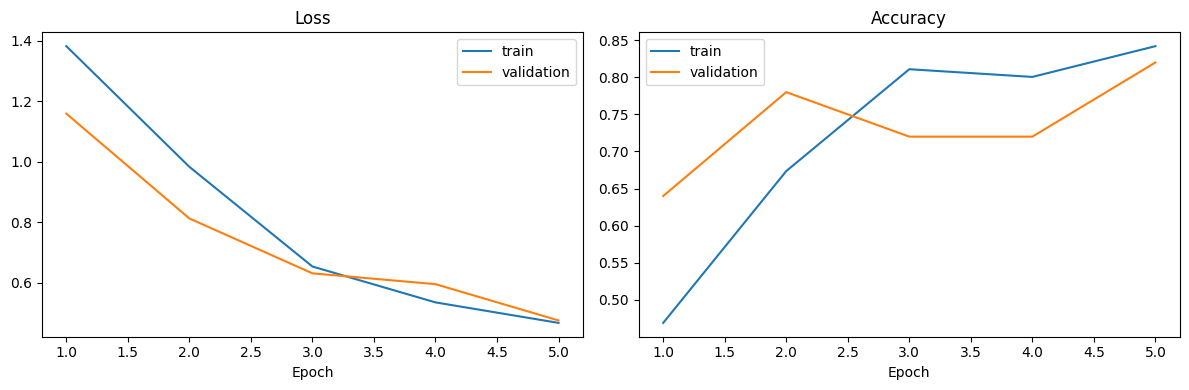

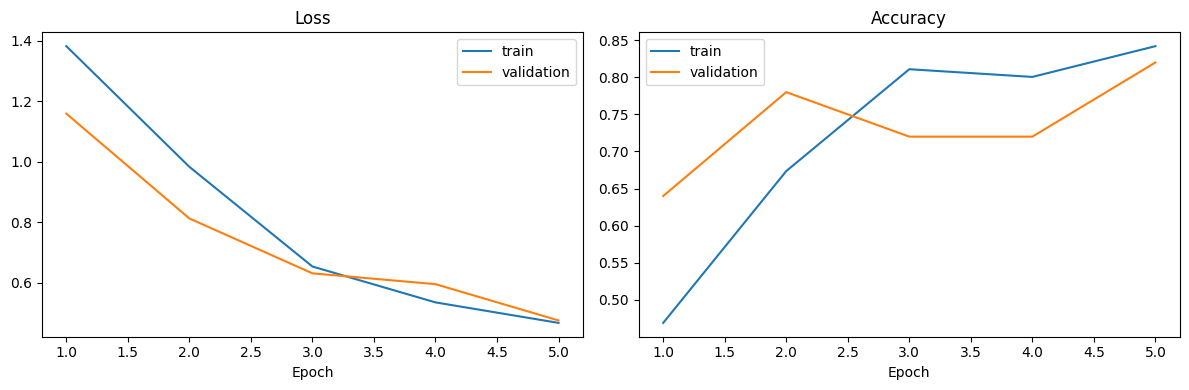

In [6]:
fig = plot_history(history, FIGURES_DIR / 'training_curves.png')
fig

## Evaluasi Awal

In [7]:
eval_split = 'test' if 'test' in loaders else 'val'
y_true, y_pred, y_prob, paths = predict_loader(model, loaders[eval_split], device)
metrics = classification_metrics(y_true, y_pred, CLASS_NAMES)
save_metrics_json(metrics, REPORTS_DIR / 'metrics_internal_demo.json')
print('Eval split:', eval_split)
print('Accuracy:', metrics['accuracy'])
print('Macro F1:', metrics['macro_f1'])

Eval split: test
Accuracy: 0.9
Macro F1: 0.9008971704623878


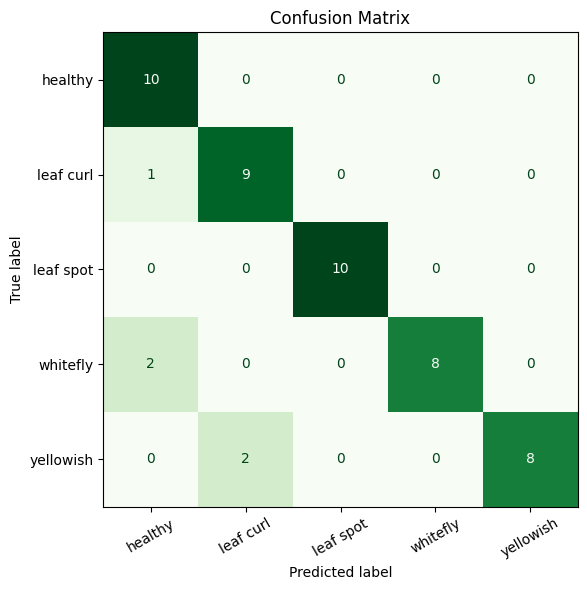

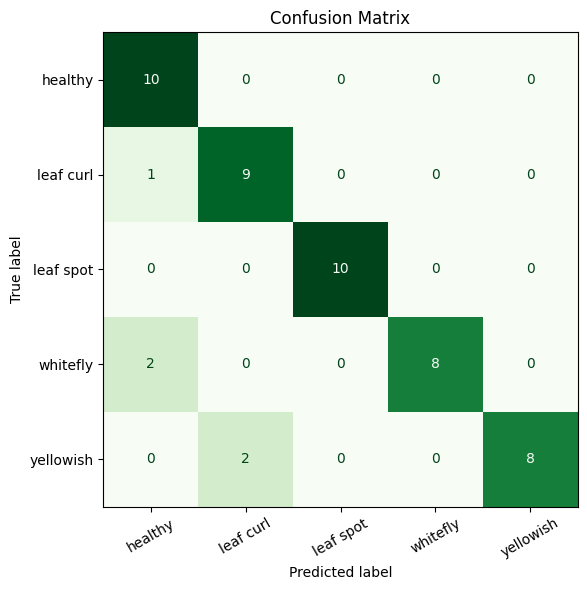

In [8]:
fig = plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, FIGURES_DIR / 'confusion_matrix_internal.png')
fig

In [9]:
preview = pd.DataFrame({
    'path': paths,
    'actual': [CLASS_NAMES[i] for i in y_true],
    'predicted': [CLASS_NAMES[i] for i in y_pred],
    'confidence': y_prob.max(axis=1),
})
display(preview.head(10))
preview.to_csv(REPORTS_DIR / 'prediction_preview_internal.csv', index=False)

,path,actual,predicted,confidence
0,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.997862
1,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.995391
2,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.998788
3,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.583535
4,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.997974
5,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.999750
6,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.608645
7,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.992900
8,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.999011
9,/Users/macbook/Documents/coding/AI/Tubes/data/...,healthy,healthy,0.992449
